# Analyse quantitative — Dataset002_Heart (20 cas)

Ce notebook calcule des métriques quantitatives pour l'ensemble des 20 cas d'entraînement
de la segmentation du ventricule gauche (left atrium) avec nnU-Net, et affiche un tableau comparatif.

Les prédictions viennent de `crossval_results_folds_0_1_2_3_4/postprocessed/` (tous les folds combinés).

**Cellules :**
1. Imports et chemins
2. Calcul des métriques pour tous les cas
3. Tableau comparatif stylisé
4. Diagramme en barres — scores Dice
5. Nuages de points — métriques vs Dice
6. Résumé des cas outliers (Dice < 0.90)
7. Analyse de l'espacement voxel (résolution spatiale par cas)

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports & chemins
#
# Tous les chemins sont dérivés de la position du notebook dans l'arborescence.
# Les IDs de cas sont extraits de summary.json (metric_per_case).
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import binary_dilation, binary_erosion
from skimage.measure import label, regionprops, marching_cubes

# ── Chemins dérivés de la position du notebook ────────────────────────────────────────
NOTEBOOK_DIR  = Path(os.getcwd()).resolve()          # .../Dataset002_Heart/analysis/
DATASET_DIR   = NOTEBOOK_DIR.parent                  # .../Dataset002_Heart/
RESULTS_BASE  = DATASET_DIR / "nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres"
DATA_BASE     = DATASET_DIR.parent.parent.parent / "data" / "Task02_Heart"
POSTPROC_DIR  = RESULTS_BASE / "crossval_results_folds_0_1_2_3_4" / "postprocessed"
SUMMARY_PATH  = POSTPROC_DIR / "summary.json"

# ── Vérification des chemins critiques ───────────────────────────────────────────
for name, path in [("DATA_BASE", DATA_BASE), ("POSTPROC_DIR", POSTPROC_DIR),
                   ("SUMMARY_PATH", SUMMARY_PATH)]:
    status = "OK" if path.exists() else "NOT FOUND"
    print(f"  {name:<14}: {path}  [{status}]")

# ── Extraction des IDs de cas depuis summary.json ──────────────────────────────────
with open(SUMMARY_PATH) as f:
    summary = json.load(f)

case_ids = [Path(c["prediction_file"]).stem for c in summary["metric_per_case"]]
print(f"\n{len(case_ids)} cas trouvés : {sorted(case_ids)}")


  DATA_BASE     : C:\Users\Walid\Documents\GitHub\Project\data\Task02_Heart  [OK]
  POSTPROC_DIR  : C:\Users\Walid\Documents\GitHub\Project\runpods\nnUNet_results\Dataset002_Heart\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\crossval_results_folds_0_1_2_3_4\postprocessed  [OK]
  SUMMARY_PATH  : C:\Users\Walid\Documents\GitHub\Project\runpods\nnUNet_results\Dataset002_Heart\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\crossval_results_folds_0_1_2_3_4\postprocessed\summary.json  [OK]

20 cas trouvés : ['la_003.nii', 'la_004.nii', 'la_005.nii', 'la_007.nii', 'la_009.nii', 'la_010.nii', 'la_011.nii', 'la_014.nii', 'la_016.nii', 'la_017.nii', 'la_018.nii', 'la_019.nii', 'la_020.nii', 'la_021.nii', 'la_022.nii', 'la_023.nii', 'la_024.nii', 'la_026.nii', 'la_029.nii', 'la_030.nii']


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Calcul des métriques pour tous les cas
#
# Pour chaque cas, on charge les volumes GT, prédiction et image brute, puis
# on calcule :
#   - dice            : depuis summary.json
#   - gt_vol_mL       : volume GT en millilitres
#   - pred_vol_mL     : volume prédit en millilitres
#   - over_under      : sur- ou sous-segmentation
#   - fp_ratio        : FP / (TP + FP)
#   - fn_ratio        : FN / GT_voxels
#   - elongation      : max(bb) / min(bb) de la boîte englobante GT
#   - sphericity      : (pi^1/3 * (6*V)^2/3) / A  -- vraie sphéricité géométrique
#   - contrast        : contraste de Michelson entre atrium et voisinage
#   - size_before_crop: dimensions originales de l'image (ZxHxW)
#   - size_after_crop : dimensions après crop non-zéro nnU-Net (ZxHxW)
# ─────────────────────────────────────────────────────────────────────────────

# Index Dice depuis summary.json pour un accès rapide par case_id
dice_lookup = {
    Path(c["prediction_file"]).stem: c["metrics"]["1"]["Dice"]
    for c in summary["metric_per_case"]
}

records = []

for case_id in sorted(case_ids):
    gt_path   = DATA_BASE / "labelsTr" / f"{case_id}.gz"
    pred_path = POSTPROC_DIR / f"{case_id}.gz"
    img_0000  = DATA_BASE / "imagesTr" / f"{case_id}_0000.nii.gz"
    img_plain = DATA_BASE / "imagesTr" / f"{case_id}.gz"
    img_path  = img_0000 if img_0000.exists() else img_plain

    # ── Chargement ──────────────────────────────────────────────────────────
    gt_nib   = nib.load(gt_path)
    pred_nib = nib.load(pred_path)
    img_nib  = nib.load(img_path)

    gt_data   = gt_nib.get_fdata().astype(np.uint8)
    pred_data = pred_nib.get_fdata().astype(np.uint8)
    img_data  = img_nib.get_fdata()

    spacing = gt_nib.header.get_zooms()[:3]
    voxel_vol_mm3 = float(spacing[0]) * float(spacing[1]) * float(spacing[2])

    # ── Dice depuis summary.json ─────────────────────────────────────
    dice = dice_lookup[case_id]

    # ── Volumes ──────────────────────────────────────────────────────────
    gt_vox   = int((gt_data == 1).sum())
    pred_vox = int((pred_data == 1).sum())
    gt_vol_mL   = gt_vox   * voxel_vol_mm3 / 1000.0
    pred_vol_mL = pred_vox * voxel_vol_mm3 / 1000.0
    over_under  = "over" if pred_vol_mL > gt_vol_mL else "under"

    # ── TP / FP / FN ─────────────────────────────────────────────────────
    TP = int(((pred_data == 1) & (gt_data == 1)).sum())
    FP = int(((pred_data == 1) & (gt_data == 0)).sum())
    FN = int(((pred_data == 0) & (gt_data == 1)).sum())

    fp_ratio = FP / (TP + FP) if (TP + FP) > 0 else 0.0
    fn_ratio = FN / gt_vox    if gt_vox    > 0 else 0.0

    # ── Élongation (boîte englobante GT) ─────────────────────────────────
    gt_labeled = label(gt_data)
    props = regionprops(gt_labeled)
    if props:
        bb = props[0].bbox          # (min_row, min_col, min_depth, max_row, max_col, max_depth)
        bb_sizes = [
            bb[3] - bb[0],
            bb[4] - bb[1],
            bb[5] - bb[2],
        ]
        bb_sizes = [s for s in bb_sizes if s > 0]
        elongation = max(bb_sizes) / min(bb_sizes) if bb_sizes else float("nan")

        # ── Vraie sphéricité géométrique : (pi^1/3 * (6*V)^2/3) / A ─────────────
        # marching_cubes calcule la surface réelle en mm² avec l'espacement réel
        try:
            verts, faces, _, _ = marching_cubes(gt_data, level=0.5, spacing=tuple(float(x) for x in spacing))
            surf_area = sum(
                0.5 * float(np.linalg.norm(
                    np.cross(verts[f[1]] - verts[f[0]], verts[f[2]] - verts[f[0]])
                ))
                for f in faces
            )
            vol_mm3 = gt_vox * voxel_vol_mm3
            sphericity = (np.pi ** (1/3) * (6 * vol_mm3) ** (2/3)) / surf_area if surf_area > 0 else float("nan")
        except Exception:
            sphericity = float("nan")
    else:
        elongation = float("nan")
        sphericity = float("nan")

    # ── Contraste de Michelson ─────────────────────────────────────────
    atrium_mask  = gt_data == 1
    dilated      = binary_dilation(gt_data, iterations=3)
    voisins_mask = dilated & (gt_data == 0)

    if atrium_mask.any() and voisins_mask.any():
        median_atrium = float(np.median(img_data[atrium_mask]))
        median_voisin = float(np.median(img_data[voisins_mask]))
        denom = median_atrium + median_voisin
        contrast = (median_atrium - median_voisin) / denom if denom != 0 else float("nan")
    else:
        contrast = float("nan")

    # ── Taille avant crop ─────────────────────────────────────────────────────
    # Dimensions brutes du volume IRM original (Z x H x W)
    s = img_data.shape
    size_before_crop = f"{s[0]}x{s[1]}x{s[2]}"

    # ── Taille après crop (bounding box non-zéro, méthode nnU-Net) ──────────────────
    # nnU-Net recadre chaque volume sur la boîte englobante des voxels non-nuls
    nz = np.nonzero(img_data)
    if len(nz[0]) > 0:
        crop_z = int(nz[0].max() - nz[0].min() + 1)
        crop_y = int(nz[1].max() - nz[1].min() + 1)
        crop_x = int(nz[2].max() - nz[2].min() + 1)
        size_after_crop = f"{crop_z}x{crop_y}x{crop_x}"
    else:
        size_after_crop = size_before_crop

    print(f"Processing {case_id}...  Dice={dice:.3f}")

    records.append({
        "case_id":           case_id,
        "dice":              dice,
        "gt_vol_mL":         gt_vol_mL,
        "pred_vol_mL":       pred_vol_mL,
        "over_under":        over_under,
        "fp_ratio":          fp_ratio,
        "fn_ratio":          fn_ratio,
        "elongation":        elongation,
        "sphericity":        sphericity,
        "contrast":          contrast,
        "size_before_crop":  size_before_crop,
        "size_after_crop":   size_after_crop,
        "sp_x":              float(spacing[0]),
        "sp_y":              float(spacing[1]),
        "sp_z":              float(spacing[2]),
        "voxel_vol_mm3":     voxel_vol_mm3,
        "anisotropie":       float(max(spacing) / min(spacing)),
    })

df = pd.DataFrame(records).sort_values("dice", ascending=True).reset_index(drop=True)
print(f"\n{len(df)} cas traités. Dice min={df['dice'].min():.3f}, max={df['dice'].max():.3f}")


Processing la_003.nii...  Dice=0.953
Processing la_004.nii...  Dice=0.933
Processing la_005.nii...  Dice=0.931
Processing la_007.nii...  Dice=0.929
Processing la_009.nii...  Dice=0.879
Processing la_010.nii...  Dice=0.918
Processing la_011.nii...  Dice=0.939
Processing la_014.nii...  Dice=0.935
Processing la_016.nii...  Dice=0.949
Processing la_017.nii...  Dice=0.936
Processing la_018.nii...  Dice=0.922
Processing la_019.nii...  Dice=0.869
Processing la_020.nii...  Dice=0.896
Processing la_021.nii...  Dice=0.936
Processing la_022.nii...  Dice=0.939
Processing la_023.nii...  Dice=0.944
Processing la_024.nii...  Dice=0.930
Processing la_026.nii...  Dice=0.930
Processing la_029.nii...  Dice=0.927
Processing la_030.nii...  Dice=0.952

20 cas traités. Dice min=0.869, max=0.953


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Tableau comparatif stylisé
#
# Affiche le DataFrame complet avec mise en couleur selon le score Dice :
#   - rouge  : Dice < 0.90
#   - orange : 0.90 <= Dice < 0.93
#   - vert   : Dice >= 0.93
# ─────────────────────────────────────────────────────────────────────────────

def color_by_dice(row):
    """Retourne un style CSS pour toutes les cellules d'une ligne selon le Dice."""
    dice = row["dice"]
    if dice < 0.90:
        bg = "background-color: #ffcccc"   # rouge clair
    elif dice < 0.93:
        bg = "background-color: #ffe0b2"   # orange clair
    else:
        bg = "background-color: #c8e6c9"   # vert clair
    return [bg] * len(row)

print("=== Tableau comparatif — 20 cas ===")

float_cols = ["dice", "gt_vol_mL", "pred_vol_mL",
              "fp_ratio", "fn_ratio", "elongation", "sphericity", "contrast"]

# Colonnes affichees dans le tableau principal (les colonnes spacing sont dans Cell 7)
display_cols = ["case_id", "dice", "gt_vol_mL", "pred_vol_mL", "over_under",
                "fp_ratio", "fn_ratio", "elongation", "sphericity", "contrast",
                "size_before_crop", "size_after_crop"]

styled = (
    df[display_cols].style
      .apply(color_by_dice, axis=1)
      .format({col: "{:.3f}" for col in float_cols})
      .set_caption("Métriques quantitatives par cas — trié par Dice croissant")
      .set_table_styles([{
          "selector": "caption",
          "props": [("font-size", "13px"), ("font-weight", "bold"),
                    ("text-align", "left"), ("padding-bottom", "6px")]
      }])
)
display(styled)


=== Tableau comparatif — 20 cas ===


,case_id,dice,gt_vol_mL,pred_vol_mL,over_under,fp_ratio,fn_ratio,elongation,sphericity,contrast,size_before_crop,size_after_crop
0,la_019.nii,0.869,116.191,91.375,under,0.013,0.224,1.574,0.662,0.184,320x320x100,224x320x100
1,la_009.nii,0.879,100.847,98.578,under,0.111,0.131,1.646,0.621,0.153,320x320x100,232x315x100
2,la_020.nii,0.896,68.586,57.506,under,0.018,0.176,1.842,0.660,0.266,320x320x110,200x320x110
3,la_010.nii,0.918,80.526,86.822,over,0.116,0.046,1.475,0.671,0.194,320x320x120,232x320x120
4,la_018.nii,0.922,86.338,76.581,under,0.019,0.130,1.744,0.629,0.217,320x320x122,232x320x122
5,la_029.nii,0.927,69.799,71.553,over,0.085,0.062,1.765,0.647,0.235,320x320x109,232x320x109
6,la_007.nii,0.929,118.685,108.380,under,0.027,0.111,1.810,0.653,0.220,320x320x130,244x320x130
7,la_024.nii,0.930,99.518,104.775,over,0.094,0.046,2.121,0.672,0.239,320x320x120,232x320x120
8,la_026.nii,0.930,115.305,123.735,over,0.101,0.036,2.147,0.690,0.197,320x320x120,232x320x120
9,la_005.nii,0.931,124.608,115.403,under,0.032,0.103,1.762,0.686,0.204,320x320x120,232x320x120


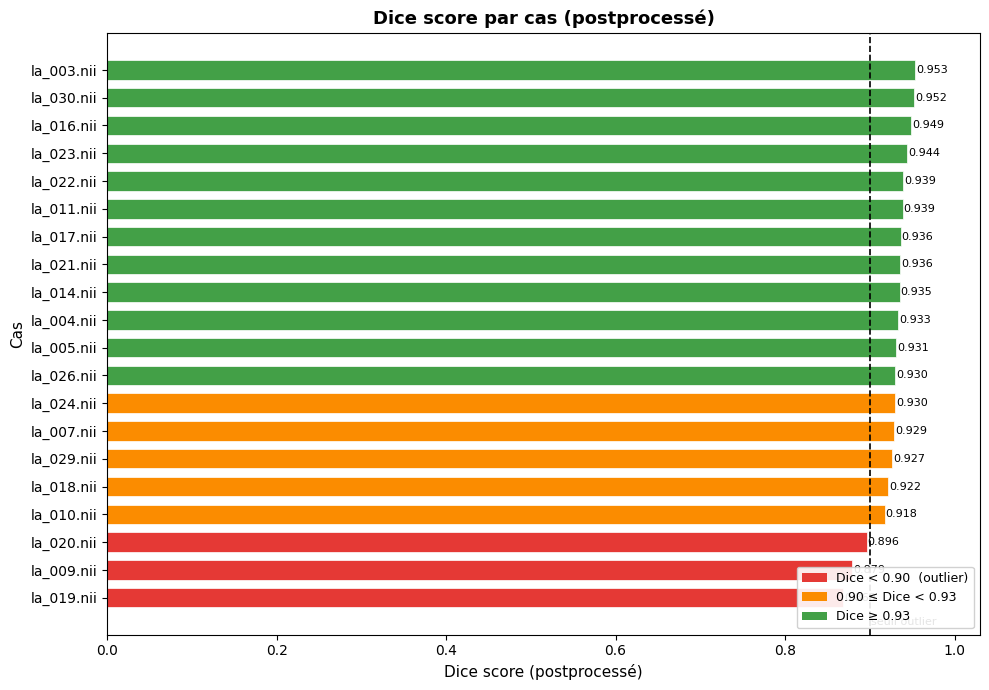

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Diagramme en barres : scores Dice par cas
#
# Barres horizontales triées par Dice croissant, colorées selon le seuil :
#   - rouge  : Dice < 0.90
#   - orange : 0.90 <= Dice < 0.93
#   - vert   : Dice >= 0.93
# Une ligne verticale pointillée marque le seuil outlier à 0.90.
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))

bar_colors = []
for d in df["dice"]:
    if d < 0.90:
        bar_colors.append("#e53935")   # rouge
    elif d < 0.93:
        bar_colors.append("#fb8c00")   # orange
    else:
        bar_colors.append("#43a047")   # vert

bars = ax.barh(
    df["case_id"], df["dice"],
    color=bar_colors, edgecolor="white", linewidth=0.5, height=0.7
)

# Valeur numérique au bout de chaque barre
for bar, val in zip(bars, df["dice"]):
    ax.text(
        val + 0.001, bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center", ha="left", fontsize=8
    )

# Ligne seuil
ax.axvline(0.90, color="black", linestyle="--", linewidth=1.2, label="seuil outlier")
ax.text(0.901, -0.7, "seuil outlier", fontsize=8, va="top")

ax.set_xlabel("Dice score (postprocessé)", fontsize=11)
ax.set_ylabel("Cas", fontsize=11)
ax.set_title("Dice score par cas (postprocessé)", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.03)

# Légende couleurs
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(facecolor="#e53935", label="Dice < 0.90  (outlier)"),
    mpatches.Patch(facecolor="#fb8c00", label="0.90 ≤ Dice < 0.93"),
    mpatches.Patch(facecolor="#43a047", label="Dice ≥ 0.93"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

C:\Users\Walid\AppData\Local\Temp\ipykernel_9896\3099852877.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


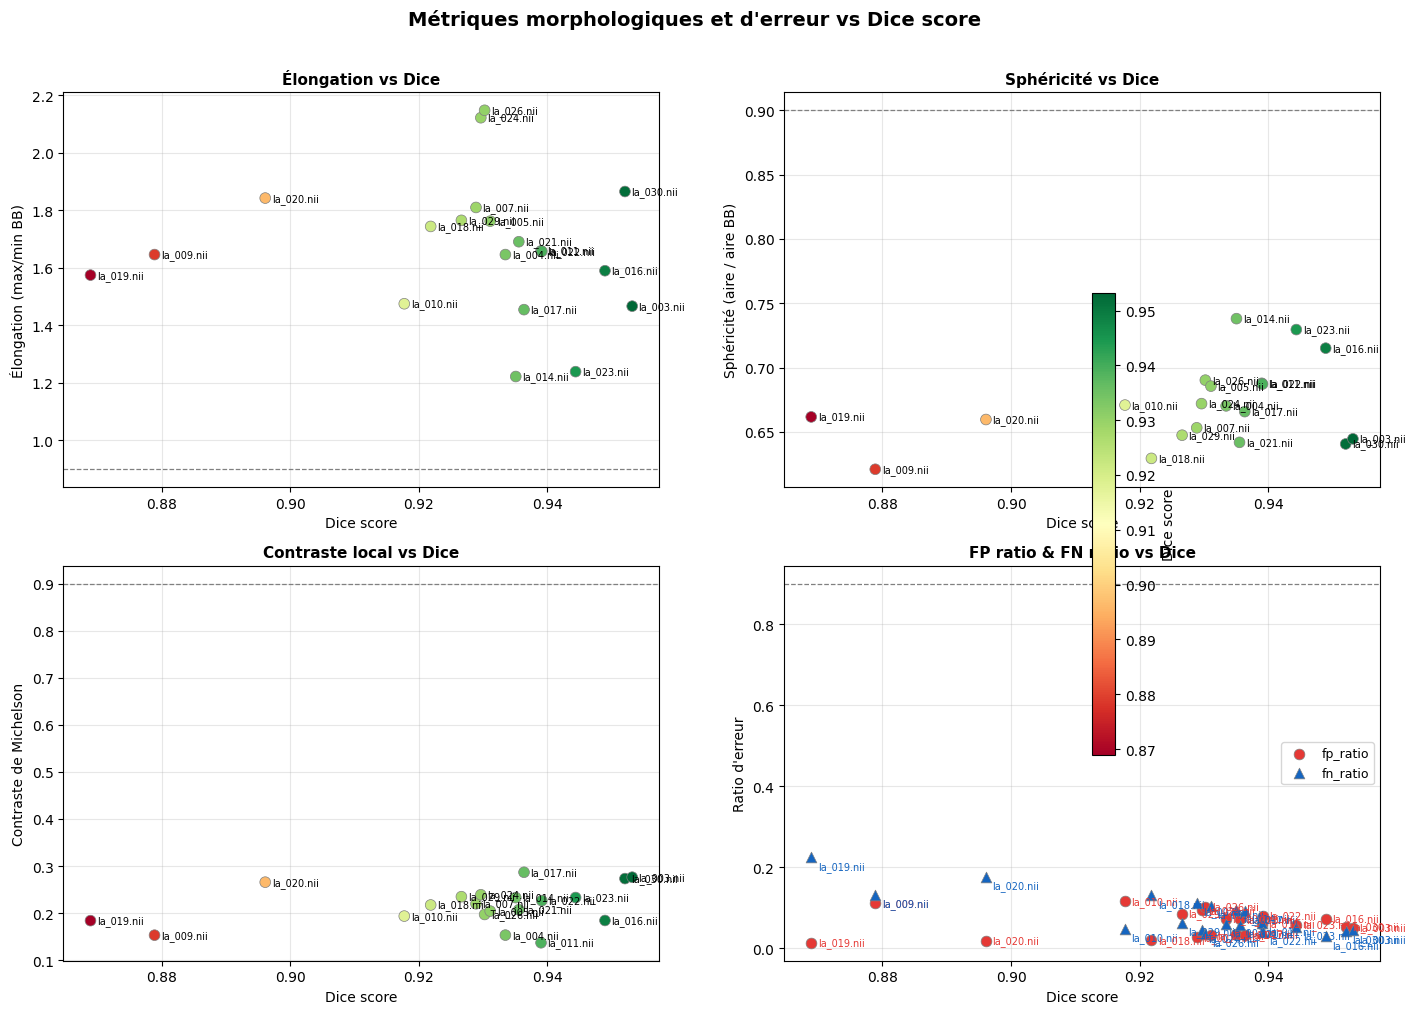

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Nuages de points : métriques vs Dice (grille 2×2)
#
# Chaque sous-figure représente une métrique en fonction du Dice score :
#   1. Élongation vs Dice
#   2. Sphéricité vs Dice
#   3. Contraste vs Dice
#   4. fp_ratio (rouge) et fn_ratio (bleu) vs Dice sur le même graphe
#
# Les points sont colorés selon le Dice (colormap RdYlGn) et étiquetés
# avec le case_id. Une ligne pointillée horizontale marque Dice = 0.90.
# ─────────────────────────────────────────────────────────────────────────────

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

cmap  = plt.get_cmap("RdYlGn")
norm  = Normalize(vmin=df["dice"].min(), vmax=df["dice"].max())
colors_scatter = [cmap(norm(d)) for d in df["dice"]]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Sous-figure 1 : Élongation vs Dice ───────────────────────
ax = axes[0, 0]
ax.scatter(df["dice"], df["elongation"], c=colors_scatter, edgecolors="grey",
           linewidth=0.5, s=60, zorder=3)
for _, row in df.iterrows():
    ax.text(row["dice"] + 0.001, row["elongation"], row["case_id"],
            fontsize=7, va="center", ha="left")
ax.axhline(y=0.90, color="grey", linestyle="--", linewidth=0.9, label="Dice = 0.90")
ax.set_xlabel("Dice score", fontsize=10)
ax.set_ylabel("Élongation (max/min BB)", fontsize=10)
ax.set_title("Élongation vs Dice", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3)

# ── Sous-figure 2 : Sphéricité vs Dice ───────────────────────
ax = axes[0, 1]
ax.scatter(df["dice"], df["sphericity"], c=colors_scatter, edgecolors="grey",
           linewidth=0.5, s=60, zorder=3)
for _, row in df.iterrows():
    ax.text(row["dice"] + 0.001, row["sphericity"], row["case_id"],
            fontsize=7, va="center", ha="left")
ax.axhline(y=0.90, color="grey", linestyle="--", linewidth=0.9, label="Dice = 0.90")
ax.set_xlabel("Dice score", fontsize=10)
ax.set_ylabel("Sphéricité (aire / aire BB)", fontsize=10)
ax.set_title("Sphéricité vs Dice", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3)

# ── Sous-figure 3 : Contraste vs Dice ────────────────────────
ax = axes[1, 0]
ax.scatter(df["dice"], df["contrast"], c=colors_scatter, edgecolors="grey",
           linewidth=0.5, s=60, zorder=3)
for _, row in df.iterrows():
    ax.text(row["dice"] + 0.001, row["contrast"], row["case_id"],
            fontsize=7, va="center", ha="left")
ax.axhline(y=0.90, color="grey", linestyle="--", linewidth=0.9, label="Dice = 0.90")
ax.set_xlabel("Dice score", fontsize=10)
ax.set_ylabel("Contraste de Michelson", fontsize=10)
ax.set_title("Contraste local vs Dice", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3)

# ── Sous-figure 4 : fp_ratio & fn_ratio vs Dice ──────────────
ax = axes[1, 1]
ax.scatter(df["dice"], df["fp_ratio"], color="#e53935", edgecolors="grey",
           linewidth=0.5, s=60, zorder=3, label="fp_ratio")
ax.scatter(df["dice"], df["fn_ratio"], color="#1565c0", edgecolors="grey",
           linewidth=0.5, s=60, zorder=3, label="fn_ratio", marker="^")
for _, row in df.iterrows():
    ax.text(row["dice"] + 0.001, row["fp_ratio"], row["case_id"],
            fontsize=7, va="center", ha="left", color="#e53935")
    ax.text(row["dice"] + 0.001, row["fn_ratio"] - 0.008, row["case_id"],
            fontsize=7, va="top",    ha="left", color="#1565c0")
ax.axhline(y=0.90, color="grey", linestyle="--", linewidth=0.9)
ax.set_xlabel("Dice score", fontsize=10)
ax.set_ylabel("Ratio d'erreur", fontsize=10)
ax.set_title("FP ratio & FN ratio vs Dice", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Barre de couleur commune ──────────────────────────────────
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.6, pad=0.02)
cbar.set_label("Dice score", fontsize=10)

fig.suptitle("Métriques morphologiques et d'erreur vs Dice score",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Résumé des cas outliers (Dice < 0.90)
#
# Affiche uniquement les cas dont le score Dice est inférieur à 0.90,
# avec toutes les colonnes du DataFrame, arrondies à 3 décimales.
# ─────────────────────────────────────────────────────────────────────────────

print("=== Cas outliers (Dice < 0.90) ===")

outliers = df[df["dice"] < 0.90].reset_index(drop=True)

if len(outliers) == 0:
    print("Aucun cas avec Dice < 0.90. Félicitations !")
else:
    print(f"{len(outliers)} cas outlier(s) détecté(s) :\n")
    display(
        outliers.style
               .format({col: "{:.3f}" for col in float_cols})
               .set_caption("Cas outliers — Dice < 0.90")
               .applymap(lambda _: "background-color: #ffcccc")
    )

=== Cas outliers (Dice < 0.90) ===
3 cas outlier(s) détecté(s) :



C:\Users\Walid\AppData\Local\Temp\ipykernel_9896\3102948298.py:20: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda _: "background-color: #ffcccc")


,case_id,dice,gt_vol_mL,pred_vol_mL,over_under,fp_ratio,fn_ratio,elongation,sphericity,contrast,size_before_crop,size_after_crop,sp_x,sp_y,sp_z,voxel_vol_mm3,anisotropie
0,la_019.nii,0.869,116.191,91.375,under,0.013,0.224,1.574,0.662,0.184,320x320x100,224x320x100,1.250000,1.250000,1.370000,2.140625,1.096000
1,la_009.nii,0.879,100.847,98.578,under,0.111,0.131,1.646,0.621,0.153,320x320x100,232x315x100,1.250000,1.250000,1.370000,2.140625,1.096000
2,la_020.nii,0.896,68.586,57.506,under,0.018,0.176,1.842,0.660,0.266,320x320x110,200x320x110,1.250000,1.250000,1.370000,2.140625,1.096000


## Section 7 — Analyse de l'espacement voxel

Cette section examine la **résolution spatiale** de chaque volume IRM :
espacement entre voxels selon les trois axes (Δx, Δy, Δz en mm),
volume élémentaire du voxel (mm³) et **anisotropie** (max / min des espacements).

Une forte anisotropie — fréquente en IRM cardiaque où la résolution dans l'axe de coupe
est plus grossière — peut rendre la segmentation plus difficile et expliquer
certains écarts de performance entre cas.

**Contenu :**
- Tableau des espacements par cas, trié par Dice croissant
- Statistiques descriptives de l'espacement
- Diagramme en barres groupées — espacement par axe et par cas
- Diagramme en barres — anisotropie par cas
- Nuage de points — anisotropie vs Dice

=== Espacement voxel par cas (trié par Dice croissant) ===


,case_id,dice,sp_x,sp_y,sp_z,voxel_vol_mm3,anisotropie
0,la_019.nii,0.869,1.250,1.250,1.370,2.1406,1.10
1,la_009.nii,0.879,1.250,1.250,1.370,2.1406,1.10
2,la_020.nii,0.896,1.250,1.250,1.370,2.1406,1.10
3,la_010.nii,0.918,1.250,1.250,1.370,2.1406,1.10
4,la_018.nii,0.922,1.250,1.250,1.370,2.1406,1.10
5,la_029.nii,0.927,1.250,1.250,1.370,2.1406,1.10
6,la_007.nii,0.929,1.250,1.250,1.370,2.1406,1.10
7,la_024.nii,0.930,1.250,1.250,1.370,2.1406,1.10
8,la_026.nii,0.930,1.250,1.250,1.370,2.1406,1.10
9,la_005.nii,0.931,1.250,1.250,1.370,2.1406,1.10



=== Statistiques descriptives de l'espacement ===
        sp_x   sp_y   sp_z  voxel_vol_mm3  anisotropie
count  20.00  20.00  20.00        20.0000       20.000
mean    1.25   1.25   1.37         2.1406        1.096
std     0.00   0.00   0.00         0.0000        0.000
min     1.25   1.25   1.37         2.1406        1.096
25%     1.25   1.25   1.37         2.1406        1.096
50%     1.25   1.25   1.37         2.1406        1.096
75%     1.25   1.25   1.37         2.1406        1.096
max     1.25   1.25   1.37         2.1406        1.096


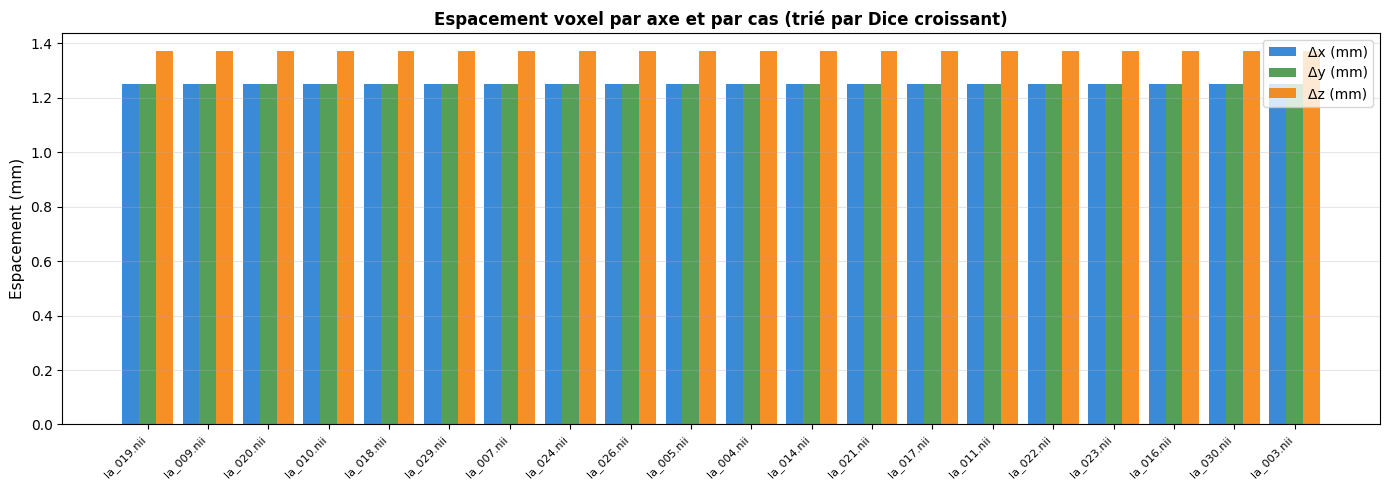

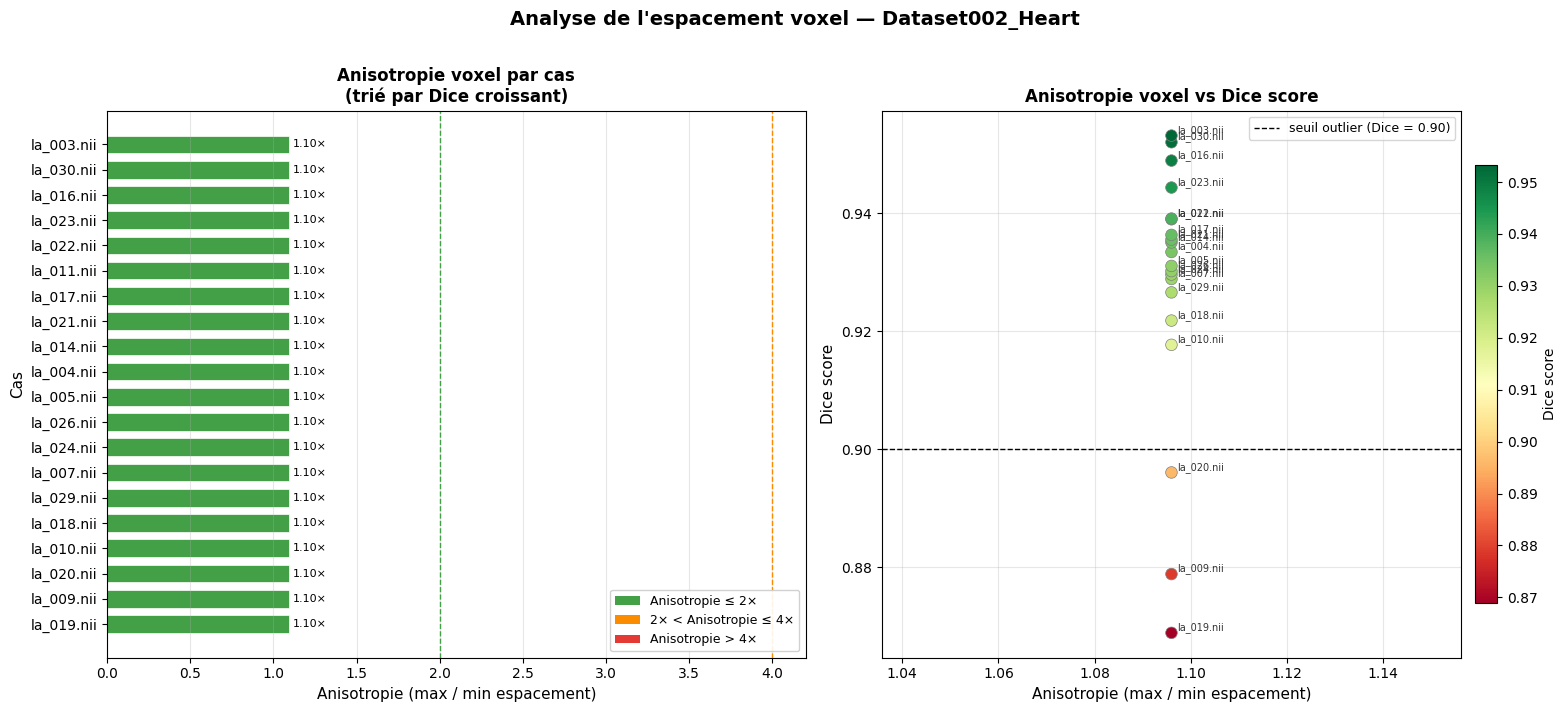


=== Corrélations de Pearson ===
  Anisotropie  ↔ Dice : r = +nan
  Δz (sp_z)    ↔ Dice : r = +nan
  Vol. voxel   ↔ Dice : r = +nan

(r proche de −1 = forte corrélation négative ; proche de 0 = pas de lien linéaire)


C:\envs\env\lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\envs\env\lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Analyse de l'espacement voxel
#
# Colonnes utilisées (ajoutées dans cell-metrics) :
#   sp_x, sp_y, sp_z  : espacement en mm selon chaque axe
#   voxel_vol_mm3     : volume élémentaire du voxel en mm³
#   anisotropie       : max(sp) / min(sp) — ratio d'anisotropie
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

spacing_cols = ["sp_x", "sp_y", "sp_z", "voxel_vol_mm3", "anisotropie"]

# ── Tableau espacement ────────────────────────────────────────────────────────
print("=== Espacement voxel par cas (trié par Dice croissant) ===")


def color_by_anisotropy(row):
    """Colore selon l'anisotropie : vert si ≤ 2×, orange si ≤ 4×, rouge sinon."""
    a = row["anisotropie"]
    if a <= 2.0:
        bg = "background-color: #c8e6c9"   # vert clair
    elif a <= 4.0:
        bg = "background-color: #ffe0b2"   # orange clair
    else:
        bg = "background-color: #ffcccc"   # rouge clair
    return [bg] * len(row)


df_sp = df[["case_id", "dice"] + spacing_cols].copy()

styled_sp = (
    df_sp.style
         .apply(color_by_anisotropy, axis=1)
         .format({"dice": "{:.3f}", "sp_x": "{:.3f}", "sp_y": "{:.3f}",
                  "sp_z": "{:.3f}", "voxel_vol_mm3": "{:.4f}", "anisotropie": "{:.2f}"})
         .set_caption("Espacement voxel par cas (mm) — couleur selon anisotropie")
         .set_table_styles([{
             "selector": "caption",
             "props": [("font-size", "13px"), ("font-weight", "bold"),
                       ("text-align", "left"), ("padding-bottom", "6px")]
         }])
)
display(styled_sp)

# ── Statistiques descriptives ─────────────────────────────────────────────────
print("\n=== Statistiques descriptives de l'espacement ===")
print(df_sp[spacing_cols].describe().round(4).to_string())

# ── Figure 1 : Espacement par axe — barres groupées ──────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 5))

x_pos = np.arange(len(df))
width = 0.28

ax1.bar(x_pos - width, df["sp_x"], width=width, label="Δx (mm)", color="#1976d2", alpha=0.85)
ax1.bar(x_pos,         df["sp_y"], width=width, label="Δy (mm)", color="#388e3c", alpha=0.85)
ax1.bar(x_pos + width, df["sp_z"], width=width, label="Δz (mm)", color="#f57c00", alpha=0.85)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(df["case_id"], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Espacement (mm)", fontsize=11)
ax1.set_title(
    "Espacement voxel par axe et par cas (trié par Dice croissant)",
    fontsize=12, fontweight="bold"
)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── Figure 2 : Anisotropie par cas (barres horizontales) ─────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))

ax_bar = axes2[0]
aniso_colors = []
for a in df["anisotropie"]:
    if a <= 2.0:
        aniso_colors.append("#43a047")   # vert
    elif a <= 4.0:
        aniso_colors.append("#fb8c00")   # orange
    else:
        aniso_colors.append("#e53935")   # rouge

bars = ax_bar.barh(
    df["case_id"], df["anisotropie"],
    color=aniso_colors, edgecolor="white", linewidth=0.5, height=0.7
)
for bar, val in zip(bars, df["anisotropie"]):
    ax_bar.text(
        val + 0.02, bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}×", va="center", ha="left", fontsize=8
    )

ax_bar.axvline(2.0, color="#43a047", linestyle="--", linewidth=1.0, label="seuil 2×")
ax_bar.axvline(4.0, color="#fb8c00", linestyle="--", linewidth=1.0, label="seuil 4×")
ax_bar.set_xlabel("Anisotropie (max / min espacement)", fontsize=11)
ax_bar.set_ylabel("Cas", fontsize=11)
ax_bar.set_title(
    "Anisotropie voxel par cas\n(trié par Dice croissant)",
    fontsize=12, fontweight="bold"
)
legend_aniso = [
    mpatches.Patch(facecolor="#43a047", label="Anisotropie ≤ 2×"),
    mpatches.Patch(facecolor="#fb8c00", label="2× < Anisotropie ≤ 4×"),
    mpatches.Patch(facecolor="#e53935", label="Anisotropie > 4×"),
]
ax_bar.legend(handles=legend_aniso, loc="lower right", fontsize=9, framealpha=0.9)
ax_bar.grid(True, alpha=0.3, axis="x")

# ── Figure 2b : Anisotropie vs Dice (nuage de points) ────────────────────────
ax_sc = axes2[1]

cmap_sp = plt.get_cmap("RdYlGn")
norm_sp = Normalize(vmin=df["dice"].min(), vmax=df["dice"].max())
colors_sp = [cmap_sp(norm_sp(d)) for d in df["dice"]]

ax_sc.scatter(
    df["anisotropie"], df["dice"],
    c=colors_sp, edgecolors="grey", linewidth=0.5, s=70, zorder=3
)
for _, row in df.iterrows():
    ax_sc.annotate(
        row["case_id"],
        xy=(row["anisotropie"], row["dice"]),
        xytext=(4, 2), textcoords="offset points",
        fontsize=7, color="#333333"
    )

ax_sc.axhline(
    0.90, color="black", linestyle="--", linewidth=1.0,
    label="seuil outlier (Dice = 0.90)"
)
ax_sc.set_xlabel("Anisotropie (max / min espacement)", fontsize=11)
ax_sc.set_ylabel("Dice score", fontsize=11)
ax_sc.set_title("Anisotropie voxel vs Dice score", fontsize=12, fontweight="bold")
ax_sc.legend(fontsize=9)
ax_sc.grid(True, alpha=0.3)

sm_sp = ScalarMappable(cmap=cmap_sp, norm=norm_sp)
sm_sp.set_array([])
cbar_sp = fig2.colorbar(sm_sp, ax=ax_sc, shrink=0.8, pad=0.02)
cbar_sp.set_label("Dice score", fontsize=10)

fig2.suptitle(
    "Analyse de l'espacement voxel — Dataset002_Heart",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ── Corrélation de Pearson : anisotropie ↔ Dice ───────────────────────────────
corr_aniso_dice = df["anisotropie"].corr(df["dice"])
corr_spz_dice   = df["sp_z"].corr(df["dice"])
corr_vol_dice   = df["voxel_vol_mm3"].corr(df["dice"])
print("\n=== Corrélations de Pearson ===")
print(f"  Anisotropie  ↔ Dice : r = {corr_aniso_dice:+.3f}")
print(f"  Δz (sp_z)    ↔ Dice : r = {corr_spz_dice:+.3f}")
print(f"  Vol. voxel   ↔ Dice : r = {corr_vol_dice:+.3f}")
print("\n(r proche de −1 = forte corrélation négative ; proche de 0 = pas de lien linéaire)")


In [ ]:
  Dice — score de segmentation                                                                                                                                 - Proche de 1 → la prédiction couvre presque parfaitement l'atrium
  - Proche de 0 → très mauvaise segmentation                                                                                                                   - Dans ce dataset : bon à partir de 0.93, outlier en dessous de 0.90

  ---
  gt_vol_mL / pred_vol_mL — volumes en millilitres
  - C'est juste la taille physique de l'atrium dans le monde réel
  - Tu les lis ensemble : si pred < gt → le modèle a manqué des zones, si pred > gt → il a segmenté trop large

  ---
  over_under — direction de l'erreur
  - over → le modèle segmente trop (inclut du tissu qui n'est pas l'atrium)
  - under → le modèle segmente trop peu (rate des parties de l'atrium)

  ---
  fp_ratio — taux de faux positifs parmi les voxels prédits
  - = "sur ce que le modèle a prédit comme atrium, quelle proportion était en réalité du background ?"
  - 0.10 → 10% des voxels prédits sont des erreurs → le modèle déborde sur les tissus voisins
  - 0.01 → presque pas de débordement

  ---
  fn_ratio — taux de faux négatifs par rapport au GT
  - = "sur tous les voxels réels de l'atrium, quelle proportion le modèle a ratée ?"
  - 0.20 → le modèle a raté 20% de l'atrium réel → il sous-segmente fortement
  - 0.04 → il en rate très peu

  ---
  elongation — à quel point l'atrium est allongé
  - = max dimension / min dimension de la boîte englobante
  - 1.0 → forme cubique, équilibrée dans les 3 axes
  - 2.0 → une dimension est 2× plus grande que l'autre → forme allongée
  - Plus c'est élevé, plus la forme est difficile à segmenter car asymétrique

  ---
  sphericity — à quel point la forme ressemble à une sphère
  - = surface réelle vs surface d'une sphère de même volume
  - 1.0 → sphère parfaite (surface minimale pour ce volume)
  - 0.62 → surface très irrégulière par rapport au volume → beaucoup de replis, de bosses
  - Plus c'est bas, plus l'atrium a une forme complexe et difficile à délimiter

  ---
  contrast — à quel point l'atrium se distingue en intensité IRM
  - = différence d'intensité médiane entre l'intérieur de l'atrium et les tissus juste autour
  - 0.28 → fort contraste → frontière claire, le modèle voit bien où s'arrête l'atrium
  - 0.15 → faible contraste → frontière floue, l'atrium et le tissu voisin ont des intensités similaires

  ---
  size_before_crop / size_after_crop — dimensions du volume en voxels (Z×H×W)
  - before → taille brute sortie du scanner
  - after → taille après que nnU-Net a coupé les bords vides (background nul)
  - La différence entre les deux montre combien de "vide" il y avait autour du patient
  - Un Z petit (ex. 90–100) → moins de coupes axiales → moins de contexte 3D pour le modèle

  ---
  sp_x / sp_y / sp_z — résolution spatiale en mm/voxel
  - Un voxel = une petite brique 3D. L'espacement dit combien de mm représente chaque brique
  - 1.25 mm → résolution fine, beaucoup de détails
  - Si sp_z est plus grand que sp_x/sp_y → les coupes axiales sont plus épaisses → moins précis dans cette direction

  ---
  anisotropie — uniformité de la résolution dans les 3 axes
  - 1.0 → même résolution dans toutes les directions (isotrope, idéal)
  - 1.5 → une direction est 50% moins précise que les autres → le modèle voit moins bien dans cet axe
  - Ici tous les cas ont 1.096 → quasi-isotrope, donc ce n'est pas un facteur différenciant dans ce dataset
